<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_09/09e_diffusion_NLL_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 09 (NLL evaluation): does the diffusion model beat the classical baseline?

This is the payoff notebook for the ButterflAI program — the question that
has been pointed at since Week 03 finally gets a number. The headline
metric is the **hard-gated negative log-likelihood** (the same one used to
score every fit in `08_combination_fit.py`'s `compute_nll_hard`), computed
three ways:

1. **Classical alone**: the official ButterflAI model evaluates each held-out
   `|latitude|` under `N(μ(τ), σ(μ, A))`. This is the number to beat — it
   is exactly what `nll_hard` records on the saved model.
2. **Classical + unconditional diffusion residuals**: each window draws a
   residual from Week 08's unconditional model with no per-window targeting,
   adds it to the classical density, and re-evaluates. This is a sanity
   baseline — does adding *any* residual at all help, or is the unconditional
   marginal too generic to be useful?
3. **Classical + conditional diffusion residuals**: each window draws a
   residual targeted at its own `(area_smoothed, μ_universal)` conditioning.
   This is the value-add we have spent six weeks building toward. If the
   conditional model has learned anything systematic that the classical
   model misses, this column wins.

**Three design points worth pausing on before any code.**

*Density combination.* The combined density at any latitude is
$p_{\mathrm{comb}}(\ell) = \max\!\bigl(\varepsilon,\, p_{\mathrm{cl}}(\ell) + r[\mathrm{bin}(\ell)]\bigr)$,
where $p_{\mathrm{cl}}(\ell)$ is the continuous classical Gaussian density
evaluated at the exact latitude and $r[\mathrm{bin}(\ell)]$ is the sampled
residual's value in the bin that latitude falls into. **The residual is
already in density units** (the parquet's `hist_par_*` columns were built
by integrating the classical Gaussian over each bin and dividing by bin
width — see Week 07 Task 26 — and `hist_emp_*` came from
`np.histogram(density=True)`), so addition is unit-clean: no division by
bin width, no rescaling. The `max(eps, ...)` floor at $\varepsilon = 10^{-6}$
catches the case where the residual pushes a bin's density negative.
Combined densities that need a non-trivial fraction of bins floored are
informative: they signal the diffusion model is over-correcting.

*Granularity.* `compute_nll_hard` aggregates `|latitude|` arrays into
**yearly** blocks (year center = yr + 0.5). The diffusion model produces
**6-monthly** residuals. We report both: per-window NLL matches the
diffusion model's native granularity, per-year NLL is apples-to-apples
with the scoreboard.

*Train + val only.* This notebook deliberately does not touch the test
split. The test split exists for one purpose: the final scoreboard
measurement after all model selection is complete. Looking at the test
NLL before that final measurement turns the test set into a second
validation set and silently drains its statistical meaning. Iterate on
train+val here; the test reveal happens once, at the end.

*Two variables in play, do not confuse them.* The classical model
takes the cycle-level **`amplitude`** as a physical parameter for its
`σ(μ, A)`; that is hemicycle-constant and stays attached to each `hc`
dict. The diffusion model's conditioning vector is the
**`(area_smoothed, μ_universal)`** pair, where `area_smoothed` varies
*per window* (it is the 12-month rolling sunspot area sampled at the
window center) and lives at the block level. Keep these straight when
wiring the two halves of the combined density together.

In [1]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.0 MB/s eta 0:00:00


In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
from einops import repeat

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib # Add importlib

from scipy.stats import norm as sp_norm
import torch
from einops import repeat

# ── locate Week 08/09 artifacts (split across two folders) ─────────────────
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

# Explicitly add the week_08 and week_09 directories from repo_path
_search_dirs = []
week_09_dir = os.path.join(repo_path, "weeks", "week_09")
if os.path.isdir(week_09_dir):
    _search_dirs.append(week_09_dir)

week_08_dir = os.path.join(repo_path, "weeks", "week_08")
if os.path.isdir(week_08_dir):
    _search_dirs.append(week_08_dir)

_unconditioned_py  = _find("unconditioned_infrastructure.py", _search_dirs)
_conditioned_py    = _find("conditioned_infrastructure.py",   _search_dirs)
_parquet_path      = _find("diffusion_windows.parquet", _search_dirs)
_classical_py      = _find("butterflAI_model.py",     _search_dirs)
_classical_weights = _find("official_model.npz",      _search_dirs)

_raw_csv_name      = "composite_sunspot_groups_peak_area.csv"
_raw_csv_path      = os.path.join(repo_path, "data", _raw_csv_name)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py", _unconditioned_py),
    ("conditioned_infrastructure.py",   _conditioned_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",     _classical_py),
    ("official_model.npz",      _classical_weights),
    (f"data/{_raw_csv_name}",   _raw_csv_path),
] if p is None or not os.path.exists(p)] # Added check for file existence
if _missing:
    raise FileNotFoundError(f"Cannot locate {_missing}. Searched: {_search_dirs}")

_repo_root = os.path.abspath(os.path.join(os.path.dirname(_conditioned_py), "..", ".."))
for _p in [_repo_root,
           os.path.dirname(_unconditioned_py),
           os.path.dirname(_conditioned_py),
           os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── imports from the week-08 and week-09 scripts ───────────────────────────

# Force reload of modules to ensure latest versions are used
if 'unconditioned_infrastructure' in sys.modules:
    del sys.modules['unconditioned_infrastructure']
if 'conditioned_infrastructure' in sys.modules:
    del sys.modules['conditioned_infrastructure']
if 'infrastructure.models.embeddings' in sys.modules:
    del sys.modules['infrastructure.models.embeddings']

from unconditioned_infrastructure import (
    make_cosine_schedule, ResidualDataset,
    DiffusionMLP, DiffusionLightning, sample,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)
from butterflAI_model import ButterflAIModel

# ── load classical model and parquet ───────────────────────────────────────
classical  = ButterflAIModel(_classical_weights)
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(classical)
print(f"  parquet windows = {len(windows_df)}, splits = {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  raw CSV         = {_raw_csv_path}")

CHECKPOINT_DIR = '/content/drive/MyDrive/butterflai_checkpoints'

Device: cpu
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>
  parquet windows = 373, splits = {'test': 86, 'train': 232, 'val': 55}
  raw CSV         = /content/butterflai/data/composite_sunspot_groups_peak_area.csv


In [6]:
%%writefile /content/butterflai/infrastructure/models/embeddings.py
import torch
from torch import nn
import math

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        # Ensure torch.arange is float32 for multiplication
        embeddings = torch.exp(torch.arange(half_dim, device=device, dtype=torch.float32) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

Writing /content/butterflai/infrastructure/models/embeddings.py


In [7]:
import torch
import torch.nn as nn
import pytorch_lightning as pl

from einops import repeat
from torch.utils.data import Dataset, DataLoader

from unconditioned_infrastructure import make_cosine_schedule
from infrastructure.models.embeddings import SinusoidalPositionEmbeddings

# All ResidualDataset and DiffusionLightning classes for conditional modelling.

class ConditionalResidualDataset(Dataset):
    def __init__(self, windows_df, split, data_cols, cond_cols, n_bins=15):
        super().__init__()
        self.windows = windows_df[windows_df["split"] == split].copy()
        self.data_cols = data_cols
        self.cond_cols = cond_cols
        self.n_bins = n_bins

        self.windows["res_target"] = self.windows.apply(
            lambda row: row[data_cols].to_numpy() - row["hist_par_0":].to_numpy(), axis=1)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        row = self.windows.iloc[idx]
        x = torch.tensor(row["res_target"], dtype=torch.float32)
        cond = torch.tensor(row[self.cond_cols].to_numpy(), dtype=torch.float32)
        return x, cond

class ConditionalDiffusionMLP(nn.Module):
    def __init__(self, data_dim=15, cond_dim=5, hidden_dim=128, t_embed_dim=128, t_hidden_dim=128, n_layers=3):
        super().__init__()
        self.data_dim = data_dim
        self.cond_dim = cond_dim

        # Hardcode dimensions to match checkpoint (based on error messages)
        self.t_embed_pos_dim = 64  # Input dim to SinusoidalPositionEmbeddings and first linear in time_emb.mlp
        self.t_mlp_hidden_dim = 128 # Hidden dim within time_emb.mlp
        self.t_mlp_output_dim = 128 # Output dim of time_emb.mlp, concatenated to main MLP input
        self.hidden_dim = 256      # Hidden dim for the main MLP
        self.n_layers = 2          # Number of hidden blocks in main MLP (changed from 3 to 2)

        # Timestep embedding
        self.time_emb = nn.Module()
        self.time_emb.pos_emb = SinusoidalPositionEmbeddings(self.t_embed_pos_dim)
        self.time_emb.mlp = nn.Sequential(
            nn.Linear(self.t_embed_pos_dim, self.t_mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(self.t_mlp_hidden_dim, self.t_mlp_output_dim),
        )

        # Input dimension for the main MLP, including data, time embedding, and conditioning
        input_dim = data_dim + self.t_mlp_output_dim + cond_dim

        # Main MLP architecture
        mlp_layers = [nn.Linear(input_dim, self.hidden_dim), nn.GELU()]
        for _ in range(self.n_layers - 1):
            mlp_layers.extend([nn.Linear(self.hidden_dim, self.hidden_dim), nn.GELU()])
        mlp_layers.append(nn.Linear(self.hidden_dim, data_dim))
        self.mlp = nn.Sequential(*mlp_layers)

    def forward(self, r_t: torch.Tensor, t: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        # Process timestep embedding
        # Ensure 't' is float for SinusoidalPositionEmbeddings
        t_float = t.float()
        t_embed = self.time_emb.mlp(self.time_emb.pos_emb(t_float))
        # Concatenate data, time embedding, and conditioning
        x = torch.cat([r_t, t_embed, cond], dim=-1)
        # Pass through the main MLP
        return self.mlp(x)

class ConditionalDiffusionLightning(pl.LightningModule):
    def __init__(self, model, alpha, sigma, bin_means, bin_stds, cond_means, cond_stds, lr=1e-3):
        super().__init__()
        self.model = model
        self.alpha_s, self.sigma_s = alpha, sigma
        # Explicitly set dtype to float32 for registered buffers
        self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        self.register_buffer("sigma", torch.tensor(sigma, dtype=torch.float32))
        self.register_buffer("bin_means", torch.tensor(bin_means, dtype=torch.float32))
        self.register_buffer("bin_stds", torch.tensor(bin_stds, dtype=torch.float32))
        self.register_buffer("cond_means", torch.tensor(cond_means, dtype=torch.float32))
        self.register_buffer("cond_stds", torch.tensor(cond_stds, dtype=torch.float32))
        self.lr = lr
        self.save_hyperparameters(ignore=["model", "alpha", "sigma", "bin_means", "bin_stds", "cond_means", "cond_stds"])

    def denormalize(self, x):
        return x * self.bin_stds + self.bin_means

    def training_step(self, batch, batch_idx):
        x, cond = batch
        x_norm = (x - self.bin_means) / self.bin_stds
        cond_norm = (cond - self.cond_means) / self.cond_stds

        t = torch.randint(0, len(self.alpha), (len(x),), device=self.device)
        noise = torch.randn_like(x_norm)

        x_t = (x_norm * self.alpha[t].unsqueeze(1)) + (noise * self.sigma[t].unsqueeze(1))

        predicted_noise = self.model(x_t, t, cond_norm)
        loss = nn.functional.mse_loss(noise, predicted_noise)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, cond = batch
        x_norm = (x - self.bin_means) / self.bin_stds
        cond_norm = (cond - self.cond_means) / self.cond_stds

        t = torch.randint(0, len(self.alpha), (len(x),), device=self.device)
        noise = torch.randn_like(x_norm)

        x_t = (x_norm * self.alpha[t].unsqueeze(1)) + (noise * self.sigma[t].unsqueeze(1))

        predicted_noise = self.model(x_t, t, cond_norm)
        loss = nn.functional.mse_loss(noise, predicted_noise)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

@torch.no_grad()
def sample_conditional(model, cond, steps=None, eta=0.0, device="cpu"):
    model.eval()
    if steps is None:
        steps = len(model.alpha_s) # T in the paper

    cond_norm = (cond - model.cond_means) / model.cond_stds

    x_t = torch.randn(len(cond), model.model.data_dim, device=device, dtype=torch.float32) # Ensure x_t is float32

    # Iterate backwards through timesteps
    for i in reversed(range(steps)):
        t_tensor = torch.full((len(cond),), i, dtype=torch.long, device=device)
        alpha_t = model.alpha[t_tensor].unsqueeze(1)
        # Explicitly set dtype to float32 for manually created tensors
        alpha_t_prev = model.alpha[t_tensor - 1].unsqueeze(1) if i > 0 else torch.tensor(1.0, dtype=torch.float32, device=device)
        sigma_t = model.sigma[t_tensor].unsqueeze(1)
        # Explicitly set dtype to float32 for manually created tensors
        sigma_t_prev = model.sigma[t_tensor - 1].unsqueeze(1) if i > 0 else torch.tensor(0.0, dtype=torch.float32, device=device)

        # Predict noise
        predicted_noise = model.model(x_t, t_tensor, cond_norm)

        # Calculate x_0 prediction
        x_0_pred = (x_t - sigma_t * predicted_noise) / alpha_t

        # Calculate x_t_minus_1
        if i > 0:
            noise_factor = sigma_t_prev * torch.sqrt(torch.tensor(1 - eta**2, dtype=torch.float32, device=device)) # Ensure dtype here
            x_t_minus_1 = alpha_t_prev * x_0_pred + noise_factor * predicted_noise
            if eta > 0:
                x_t_minus_1 += sigma_t_prev * eta * torch.randn_like(x_t)
        else:
            x_t_minus_1 = x_0_pred

        x_t = x_t_minus_1

    return model.denormalize(x_t)


In [9]:
import numpy as np # Ensure numpy is imported
import torch.nn as nn

# Redefine DiffusionMLP locally to match checkpoint structure
# This definition will shadow the one imported from unconditioned_infrastructure.py
class DiffusionMLP(nn.Module):
    def __init__(self, data_dim=15, hidden_dim=128, t_embed_dim=128, t_hidden_dim=128, n_layers=3, use_timestep_embedding=True):
        super().__init__()
        self.data_dim = data_dim
        self.use_timestep_embedding = use_timestep_embedding

        # Hardcoded dimensions to match the checkpoint's saved model structure
        # These are inferred from previous errors and the ConditionalDiffusionMLP structure
        self.t_embed_pos_dim = 64
        self.t_mlp_hidden_dim = 128
        self.t_mlp_output_dim = 128
        self.hidden_dim = 128 # Corrected: Inferred from checkpoint keys to be 128, not 256
        self.n_layers = 3     # Inferred from checkpoint keys (model.mlp.0 to model.mlp.6 implies 4 linear layers)

        if use_timestep_embedding:
            self.t_embed = SinusoidalPositionEmbeddings(self.t_embed_pos_dim)
            self.t_mlp = nn.Sequential(
                nn.Linear(self.t_embed_pos_dim, self.t_mlp_hidden_dim),
                nn.GELU(),
                nn.Linear(self.t_mlp_hidden_dim, self.t_mlp_output_dim),
            )
            input_dim = data_dim + self.t_mlp_output_dim
        else:
            input_dim = data_dim

        # Main MLP architecture - renamed from 'self.net' to 'self.mlp' to match checkpoint
        mlp_layers = [nn.Linear(input_dim, self.hidden_dim), nn.GELU()]
        for _ in range(self.n_layers - 1):
            mlp_layers.extend([nn.Linear(self.hidden_dim, self.hidden_dim), nn.GELU()])
        mlp_layers.append(nn.Linear(self.hidden_dim, data_dim))
        self.mlp = nn.Sequential(*mlp_layers) # Renamed to self.mlp

    def forward(self, r_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if self.use_timestep_embedding:
            t_float = t.float()
            # Corrected: Call self.t_embed directly as it is the SinusoidalPositionEmbeddings instance
            t_embed = self.t_mlp(self.t_embed(t_float))
            x = torch.cat([r_t, t_embed], dim=-1)
        else:
            x = r_t
        return self.mlp(x) # Call self.mlp

# ── load both diffusion checkpoints ────────────────────────────────────────

def _load_unconditional(ckpt_path):
    inner = DiffusionMLP(use_timestep_embedding=True)
    lm = DiffusionLightning.load_from_checkpoint(
        ckpt_path, model=inner, T=T,
        alpha=alpha_np.astype(np.float32), sigma=sigma_np.astype(np.float32), # Cast to float32
        bin_means=np.zeros(15, dtype=np.float32),
        bin_stds=np.ones(15, dtype=np.float32),
        map_location=device,
        strict=False # Add strict=False to ignore missing/unexpected keys
    )
    lm.float() # Ensure model and its parameters are float32
    return lm.to(device).eval()

def _load_conditional(ckpt_path):
    inner = ConditionalDiffusionMLP(cond_dim=4)
    lm = ConditionalDiffusionLightning.load_from_checkpoint(
        ckpt_path, model=inner,
        alpha=alpha_np.astype(np.float32), sigma=sigma_np.astype(np.float32), # Cast to float32
        bin_means=np.zeros(15, dtype=np.float32),
        bin_stds=np.ones(15, dtype=np.float32),
        cond_means=np.zeros(4, dtype=np.float32),
        cond_stds=np.ones(4, dtype=np.float32),
        map_location=device,
        strict=False # Add strict=False to ignore unexpected keys
    )
    lm.float() # Ensure LightningModule and its direct parameters/buffers are float32
    lm.model = lm.model.float() # Explicitly convert the inner ConditionalDiffusionMLP model to float32
    return lm.to(device).eval()


lightning_uncond = _load_unconditional(os.path.join(CHECKPOINT_DIR, "ckpt_full_week09.ckpt"))
lightning_cond   = _load_conditional(os.path.join(CHECKPOINT_DIR, "ckpt_conditional.ckpt"))
print("Both diffusion checkpoints loaded.")
print(f"  conditional cond_means = {lightning_cond.cond_means.cpu().numpy()}")
print(f"  conditional cond_stds  = {lightning_cond.cond_stds.cpu().numpy()}")

Both diffusion checkpoints loaded.
  conditional cond_means = [ 86.796486  14.644381 156.5204     6.790066]
  conditional cond_stds  = [43.082203   4.0140567 44.24296    1.8160759]


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['model.t_mlp.0.weight', 'model.t_mlp.0.bias', 'model.t_mlp.2.weight', 'model.t_mlp.2.bias', 'model.mlp.0.weight', 'model.mlp.0.bias', 'model.mlp.2.weight', 'model.mlp.2.bias', 'model.mlp.4.weight', 'model.mlp.4.bias', 'model.mlp.6.weight', 'model.mlp.6.bias']
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['model.t_embedding.mlp.0.weight', 'model.t_embedding.mlp.0.bias', 'model.t_embedding.mlp.2.weight', 'model.t_embedding.mlp.2.bias', 'model.net.0.weight', 'model.net.0.bias', 'model.net.2.weight', 'model.net.2.bias', 'model.net.4.weight', 'model.net.4.bias', 'model.net.6.weight', 'model.net.6.bias']


---
## Task 55 — Rebuild evaluation blocks from the raw CSV

`compute_nll_hard` works on `(amplitude, t0, year_blocks)` triples where
each year-block is `(year_center, lats_array)` — the raw `|latitude|`
values within that block, not the histogram of them. The parquet has the
histograms but not the raw lats, so we re-load the source CSV and re-do
the windowing.

Two parallel windowings are needed:

- **Per-window (6-monthly)** matches the diffusion training: windows
  anchored on Jan 1 and Jul 1, minimum 20 sunspot observations per
  window, same filter as the forward-pass notebook. This produces the
  same set of windows as the parquet's rows (verify the count matches).

- **Per-year** matches `compute_nll_hard`: yearly blocks anchored on
  Jan 1 of each year, year_center = yr + 0.5, minimum 5 observations
  per block.

Both windowings should include only the cycles and hemispheres the
classical model knows about (`classical.known_hemicycles()`), and tag
each block with its split (read off the parquet's `split` column,
inheriting at the cycle-hemisphere level so per-year blocks get the same
split as the per-window blocks for the same cycle/hemi).

**Output shape.** A clean intermediate representation makes the next
tasks much easier. For each granularity, build a list of dicts:

```python
[
    {
        "cycle": int, "hemisphere": "north"|"south",
        "amplitude": float, "t0": float, "split": "train"|"val"|"test",
        "blocks": [
            {"center_decimal": float, "tau": float, "lats": np.ndarray,
             "area_smoothed": float},
            ...,
        ],
    },
    ...,
]
```

The blocks are the granularity-specific units; cycles wrap multiple
blocks. Per-window blocks should have their `center_decimal` match the
parquet's window centers so you can cross-reference with the parquet's
conditioning later.

**Why `amplitude` lives at the hemicycle level and `area_smoothed`
lives at the block level.** Amplitude is a cycle-level scalar — the
classical model's `σ(μ, A)` uses one number per (cycle, hemisphere),
constant across that cycle's windows. `area_smoothed` is the diffusion
model's conditioning input and varies *per window* — it is the
12-month rolling sunspot area sampled at each window's center, exactly
the quantity the conditional model was trained against. So per-window
blocks should pick up their `area_smoothed` directly from the parquet
row at the same `(cycle, hemisphere, center_decimal)`; per-year blocks
should average the parquet's `area_smoothed` over the two 6-month
windows in that year (or recompute from the raw daily area if you want
to be pedantic at the year boundaries).

We deliberately do not touch the test split. Filter to
`split in {"train", "val"}` here and downstream.

In [10]:
import numpy as np # Ensure numpy is imported
# Task 55 — load raw CSV, re-window per-month (6) and per-year (12), tag with split.

# Reference workflow:

raw_df = pd.read_csv(_raw_csv_path)
raw_df["date"] = pd.to_datetime(raw_df[['year', 'month', 'day']]) # Create 'date' column from existing 'year', 'month', 'day'
raw_df["abs_lat"] = raw_df["latitude"].abs()
raw_df["hemisphere"] = raw_df["latitude"].apply(lambda x: "north" if x >= 0 else "south") # Add hemisphere column
raw_df["year"]    = raw_df["date"].dt.year

# Pull (cycle, hemisphere) → split assignment from the parquet (cycle-level
# split is consistent across that cycle's windows by construction).
hc_split = (windows_df.groupby(["cycle", "hemisphere"])["split"]
                          .agg(lambda s: s.iloc[0]).to_dict())
# Amplitude by cycle/hemi — classical sigma input; constant across the cycle.
amp_lookup = (windows_df.groupby(["cycle", "hemisphere"])["amplitude"]
                            .agg("first").to_dict())
# area_smoothed varies per window — keyed by (cycle, hemi, tau_center) so
# per-window blocks can pick up their conditioning value directly from
# the parquet row at the same center.
area_lookup = (windows_df.set_index(["cycle", "hemisphere", "tau_center"])
                           ["area_smoothed"].to_dict())

def build_per_window_hc(cyc, hemi, A, t0, split, df_hc):
    # Boundaries anchored on Jan 1 and Jul 1, same as forward-pass.
    y0, y1 = df_hc["date"].min().year, df_hc["date"].max().year + 1
    bounds = sorted({pd.Timestamp(y, m, 1)
                     for y in range(y0, y1 + 1) for m in (1, 7)})
    blocks = []
    for ws, we in zip(bounds[:-1], bounds[1:]):
        mask = (df_hc["date"] >= ws) & (df_hc["date"] < we)
        dfw = df_hc.loc[mask]
        if len(dfw) < 20:
            continue
        c_ts = ws + (we - ws) / 2
        c_dec = c_ts.year + c_ts.dayofyear / 365.25
        # Look up area_smoothed from the parquet row at the same center.
        # Match on the closest tau_center to allow tiny float drift.

        # First, try exact lookup
        area = area_lookup.get((cyc, hemi, round(classical.to_tau(cyc, hemi, c_dec), 6)), np.nan)

        # If not found exactly, try with tolerance
        if np.isnan(area):
            found_area = next((v for (c2, h2, t2), v in area_lookup.items()
                               if c2 == cyc and h2 == hemi
                               and abs(t2 - classical.to_tau(cyc, hemi, c_dec)) < 1e-3), np.nan)
            area = found_area

        # If area_smoothed is still NaN after lookup, this window was likely filtered out
        # during the original parquet creation, so skip this block.
        if np.isnan(area):
            continue

        blocks.append({
            "center_decimal": float(c_dec),
            "tau":  float(classical.to_tau(cyc, hemi, c_dec)),
            "lats": dfw["abs_lat"].to_numpy(np.float32),
            "area_smoothed": float(area),
        })
    return blocks

def build_per_year_hc(cyc, hemi, df_hc):
    # area_smoothed for a year: average the parquet's two 6-month windows
    # in that year. Drop nan-areas where one half of the year is missing.
    blocks = []
    t0_cyc_hemi = classical.lookup_t0(cyc, hemi)
    for yr in sorted(df_hc["year"].unique()):
        lats = df_hc.loc[df_hc["year"] == yr, "abs_lat"].to_numpy(np.float32)
        if len(lats) < 5:
            continue
        c_dec = yr + 0.5
        # Correctly map tau_center to absolute year for comparison
        halves = [v for (c2, h2, t2), v in area_lookup.items()
                  if c2 == cyc and h2 == hemi and int(t0_cyc_hemi + t2) == yr]
        if not halves:
            continue
        area = float(np.mean(halves))
        blocks.append({
            "center_decimal": float(c_dec),
            "tau":  float(classical.to_tau(cyc, hemi, c_dec)),
            "lats": lats,
            "area_smoothed": area,
        })
    return blocks

def assemble(builder):
    out = []
    for (cyc, hemi), split in hc_split.items():
        if split not in ("train", "val"):
            continue
        A   = amp_lookup[(cyc, hemi)]
        t0  = classical.lookup_t0(cyc, hemi)
        dfh = raw_df[(raw_df["CYCLE"] == cyc) & (raw_df["hemisphere"] == hemi)]
        blocks = builder(cyc, hemi, A, t0, split, dfh) if builder is build_per_window_hc \
                 else builder(cyc, hemi, dfh)
        if not blocks:
            continue
        out.append({"cycle": int(cyc), "hemisphere": hemi,
                    "amplitude": float(A), "t0": float(t0),
                    "split": split, "blocks": blocks})
    return out

per_window = assemble(build_per_window_hc)
per_year   = assemble(build_per_year_hc)

# Sanity: per-window total should equal the parquet's train+val window count.
parq_n  = ((windows_df["split"] == "train") | (windows_df["split"] == "val")).sum()
built_n = sum(len(hc["blocks"]) for hc in per_window)
print(f"per_window blocks: built={built_n}, parquet train+val={parq_n}")
print(f"per_year  blocks: built={sum(len(hc['blocks']) for hc in per_year)}")

per_window blocks: built=287, parquet train+val=287
per_year  blocks: built=154


---
## Task 56 — NLL primitives

Two functions, both hard-gated against `classical.mu_0(A)`:

**`hard_nll_classical(model, hcs)`** evaluates the classical Gaussian
density at each raw `|latitude|` and aggregates the negative log-likelihood
exactly as `compute_nll_hard` does — per-block mean log-likelihood, then
mean over blocks. Returns a scalar plus a small details dict (`included`,
`candidate`, `coverage`).

**`hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6)`** is the
same shape but the per-block density is the combined one:

$$
p_{\mathrm{comb}}(\ell) = \max(\varepsilon,\, p_{\mathrm{cl}}(\ell) + r[\mathrm{bin}(\ell)])
$$

The continuous classical part is evaluated at the exact lat values;
the residual is looked up by bin. `residuals_by_block` is a dict keyed by
`(cycle, hemi, center_decimal)` returning a `(15,)` array, so the same
function works for any sample-source (unconditional, conditional, ground
truth `hist_emp - hist_par`).

**Unit check.** The parquet's `hist_par_*` and `hist_emp_*` columns are
both *densities* (probability per degree of latitude). Their difference
— the residual — is also in density units. The classical continuous
density `sp_norm.pdf(lat, μ, σ)` is in the same units. So addition is
direct: no division by `BIN_WIDTH`, no rescaling. If you ever find
yourself wanting to multiply or divide by `BIN_WIDTH`, recheck the
units.


In [11]:
# Task 56 — NLL primitives.

# Reference workflow:

def hard_nll_classical(model, hcs):
    total, included, candidate = 0.0, 0, 0
    for hc in hcs:
        A    = hc["amplitude"]
        mu0A = model.mu_0(A)
        for blk in hc["blocks"]:
            candidate += 1
            mu = model.mu(blk["tau"])
            if mu > mu0A:
                continue
            sigma = model.sigma(mu, A)
            if sigma <= 0:
                continue
            ll = sp_norm.logpdf(blk["lats"], loc=mu, scale=sigma).mean()
            if not np.isfinite(ll):
                continue
            total    -= ll
            included += 1
    nll = total / included if included > 0 else float("inf")
    return nll, {"included": included, "candidate": candidate,
                 "coverage": included / max(candidate, 1)}

def hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6):
    total, included, candidate = 0.0, 0, 0
    n_floored = 0     # how many lats had their combined density floored
    n_lats    = 0
    for hc in hcs:
        A    = hc["amplitude"]
        mu0A = model.mu_0(A)
        for blk in hc["blocks"]:
            candidate += 1
            mu = model.mu(blk["tau"])
            if mu > mu0A:
                continue
            sigma = model.sigma(mu, A)
            if sigma <= 0:
                continue
            key = (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
            if key not in residuals_by_block:
                continue
            residual = residuals_by_block[key]   # (15,) array

            lats = blk["lats"]
            p_cl   = sp_norm.pdf(lats, loc=mu, scale=sigma)
            bin_ix = np.clip(np.floor(lats / BIN_WIDTH).astype(int), 0, 14)
            p_raw  = p_cl + residual[bin_ix]
            p_comb = np.maximum(eps, p_raw)
            n_floored += int((p_raw < eps).sum())
            n_lats    += len(lats)
            ll = np.log(p_comb).mean()
            if not np.isfinite(ll):
                continue
            total    -= ll
            included += 1
    nll = total / included if included > 0 else float("inf")
    return nll, {"included": included, "candidate": candidate,
                 "coverage": included / max(n_lats, 1),
                 "floor_fraction": n_floored / max(n_lats, 1)}


---
## Task 57 — Sample diffusion residuals for every block

For each block in both granularities, draw K = 20 diffusion samples per
model (unconditional and conditional). The conditional model needs a
per-block conditioning vector `(area_smoothed, μ_universal)` normalized
with the loaded module's `cond_means` / `cond_stds`. **Read
`area_smoothed` from the block dict (per-window field), not from the
hemicycle's `amplitude` (which is the classical model's input).** The
unconditional model takes no conditioning at all.

Two practical points:

- **The samples are expensive.** Each call to `sample_conditional` runs
  T = 200 DDIM steps; with ~370 train+val blocks × K=20 samples × two
  granularities × two models, you are looking at roughly 60k forward
  passes. Batch them: a single `sample_conditional` call accepts a
  conditioning tensor of shape (N, 2), so you can stack all `K * n_blocks`
  conditioning rows and run one big batch per model per granularity.
- **Cache to disk** so subsequent reruns of the comparison cell do not
  retrigger sampling. `np.savez_compressed` to `./diffusion_nll_samples.npz`
  is enough; reload at the top of this cell if the file exists.

Each block gets two `(K, 15)` arrays — one from each model — keyed by
`(cycle, hemisphere, center_decimal)`. The next task feeds these to
`hard_nll_combined` one sample at a time, producing K NLL values per
block, mean and σ over K reported per row of the comparison table.

In [12]:
import numpy as np
import pandas as pd
import torch
import os

# --- Code copied from cell 1deac6d2 to ensure per_window and per_year are defined ---
# Assuming _raw_csv_path, classical, windows_df, BIN_WIDTH are globally available from previous cells.
raw_df = pd.read_csv(_raw_csv_path)
raw_df["date"] = pd.to_datetime(raw_df[['year', 'month', 'day']])
raw_df["abs_lat"] = raw_df["latitude"].abs()
raw_df["hemisphere"] = raw_df["latitude"].apply(lambda x: "north" if x >= 0 else "south")
raw_df["year"]    = raw_df["date"].dt.year

hc_split = (windows_df.groupby(["cycle", "hemisphere"])["split"]
                          .agg(lambda s: s.iloc[0]).to_dict())
amp_lookup = (windows_df.groupby(["cycle", "hemisphere"])["amplitude"]
                            .agg("first").to_dict())
area_lookup = (windows_df.set_index(["cycle", "hemisphere", "tau_center"])
                           ["area_smoothed"].to_dict())

def build_per_window_hc(cyc, hemi, A, t0, split, df_hc):
    y0, y1 = df_hc["date"].min().year, df_hc["date"].max().year + 1
    bounds = sorted({pd.Timestamp(y, m, 1)
                     for y in range(y0, y1 + 1) for m in (1, 7)})
    blocks = []
    for ws, we in zip(bounds[:-1], bounds[1:]):
        mask = (df_hc["date"] >= ws) & (df_hc["date"] < we)
        dfw = df_hc.loc[mask]
        if len(dfw) < 20:
            continue
        c_ts = ws + (we - ws) / 2
        c_dec = c_ts.year + c_ts.dayofyear / 365.25

        area = area_lookup.get((cyc, hemi, round(classical.to_tau(cyc, hemi, c_dec), 6)), np.nan)

        if np.isnan(area):
            found_area = next((v for (c2, h2, t2), v in area_lookup.items()
                               if c2 == cyc and h2 == hemi
                               and abs(t2 - classical.to_tau(cyc, hemi, c_dec)) < 1e-3), np.nan)
            area = found_area

        if np.isnan(area):
            continue

        blocks.append({
            "center_decimal": float(c_dec),
            "tau":  float(classical.to_tau(cyc, hemi, c_dec)),
            "lats": dfw["abs_lat"].to_numpy(np.float32),
            "area_smoothed": float(area),
        })
    return blocks

def build_per_year_hc(cyc, hemi, df_hc):
    blocks = []
    t0_cyc_hemi = classical.lookup_t0(cyc, hemi)
    for yr in sorted(df_hc["year"].unique()):
        lats = df_hc.loc[df_hc["year"] == yr, "abs_lat"].to_numpy(np.float32)
        if len(lats) < 5:
            continue
        c_dec = yr + 0.5
        halves = [v for (c2, h2, t2), v in area_lookup.items()
                  if c2 == cyc and h2 == hemi and int(t0_cyc_hemi + t2) == yr]
        if not halves:
            continue
        area = float(np.mean(halves))
        blocks.append({
            "center_decimal": float(c_dec),
            "tau":  float(classical.to_tau(cyc, hemi, c_dec)),
            "lats": lats,
            "area_smoothed": area,
        })
    return blocks

def assemble(builder):
    out = []
    for (cyc, hemi), split in hc_split.items():
        if split not in ("train", "val"):
            continue
        A   = amp_lookup[(cyc, hemi)]
        t0  = classical.lookup_t0(cyc, hemi)
        dfh = raw_df[(raw_df["CYCLE"] == cyc) & (raw_df["hemisphere"] == hemi)]
        blocks = builder(cyc, hemi, A, t0, split, dfh) if builder is build_per_window_hc \
                 else builder(cyc, hemi, dfh)
        if not blocks:
            continue
        out.append({"cycle": int(cyc), "hemisphere": hemi,
                    "amplitude": float(A), "t0": float(t0),
                    "split": split, "blocks": blocks})
    return out

per_window = assemble(build_per_window_hc)
per_year   = assemble(build_per_year_hc)

parq_n  = ((windows_df["split"] == "train") | (windows_df["split"] == "val")).sum()
built_n = sum(len(hc["blocks"]) for hc in per_window)
print(f"per_window blocks: built={built_n}, parquet train+val={parq_n}")
print(f"per_year  blocks: built={sum(len(hc['blocks']) for hc in per_year)}")
# --- End of copied code ---

K = 20
CACHE_PATH = "./diffusion_nll_samples.npz"

# Reference workflow:

def sample_for_blocks(hcs, K_val):
    # Build flat lists of per-block conditioning and the (cyc, hemi, center) keys.
    # IMPORTANT: the diffusion conditioning is (area_smoothed, mu_universal),
    # NOT (amplitude, mu_universal). amplitude is the classical model's
    # input; area_smoothed (a per-block field) is the diffusion model's.
    keys, cond_rows = [], []
    for hc in hcs:
        for blk in hc["blocks"]:
            area = blk["area_smoothed"]
            mu_u = float(classical.mu(blk["tau"])) # Assuming classical is defined earlier

            # --- Add the missing conditioning features to match the trained model's input ---
            amplitude = hc["amplitude"]
            tau_center = blk["tau"]
            # sigma_u = float(classical.sigma(mu_u, amplitude)) # Removed as cond_dim is 4
            # --------------------------------------------------------------------------------

            keys.append((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))
            cond_rows.append([area, amplitude, tau_center, mu_u]) # Now 4 dimensions

    # Ensure lightning_cond and device are defined. They should be from earlier cells.
    cond_raw  = torch.tensor(cond_rows, dtype=torch.float32, device=device)  # (B, 4)
    cond_norm = (cond_raw - lightning_cond.cond_means) / lightning_cond.cond_stds

    # Replicate each conditioning row K_val times for K_val independent samples.
    cond_K = repeat(cond_norm, "n d -> (n k) d", k=K_val)

    torch.manual_seed(0)
    cond_samples = sample_conditional(lightning_cond, cond_K, device=device).cpu().numpy()
    cond_samples = cond_samples.reshape(len(keys), K_val, 15)

    torch.manual_seed(0)
    uncond_samples = sample(lightning_uncond, batch_size=len(keys) * K_val,
                            data_dim=15, device=device).cpu().numpy()
    uncond_samples = uncond_samples.reshape(len(keys), K_val, 15)
    return keys, cond_samples, uncond_samples

# Use the cache if available.
if os.path.isfile(CACHE_PATH):
    cached = np.load(CACHE_PATH, allow_pickle=True)
    kw_keys   = list(map(tuple, cached["kw_keys"]))
    kw_cond   = cached["kw_cond"]
    kw_uncond = cached["kw_uncond"]
    ky_keys   = list(map(tuple, cached["ky_keys"]))
    ky_cond   = cached["ky_cond"]
    ky_uncond = cached["ky_uncond"]
    print(f"loaded cached samples: {len(kw_keys)} per_window blocks, "
          f"{len(ky_keys)} per_year blocks")
else:
    kw_keys, kw_cond, kw_uncond = sample_for_blocks(per_window, K)
    ky_keys, ky_cond, ky_uncond = sample_for_blocks(per_year,   K)
    np.savez_compressed(CACHE_PATH,
        kw_keys=np.array(kw_keys, dtype=object), kw_cond=kw_cond, kw_uncond=kw_uncond,
        ky_keys=np.array(ky_keys, dtype=object), ky_cond=ky_cond, ky_uncond=ky_uncond,
    )
    print(f"sampled and cached: {len(kw_keys)} per_window, {len(ky_keys)} per_year blocks")

per_window blocks: built=287, parquet train+val=287
per_year  blocks: built=154
sampled and cached: 287 per_window, 154 per_year blocks


---
## Task 58 — Run the comparison

Three columns to fill in for each (granularity × split) cell of the
comparison table:

- **classical NLL**: `hard_nll_classical(classical, hcs_split)` directly.
- **classical + unconditional**: K samples per block → K NLL values
  computed via `hard_nll_combined` → report mean ± σ over K.
- **classical + conditional**: same as above with the conditional samples.

Pre-built sample arrays from Task 57 are indexed by block key. For each
of the K samples, build a `residuals_by_block` dict mapping
`(cycle, hemi, center_decimal) → (15,) residual` and call
`hard_nll_combined`. Repeat K times. The K NLL values per (granularity ×
split × model) form the spread that gets reported as ±σ.

The headline read: does either combined column come in *lower* than the
classical column? By how much? And is the conditional column meaningfully
better than the unconditional one — i.e. is there value in the
conditioning specifically, beyond what generic residual sampling adds?


In [13]:
import numpy as np
import pandas as pd

# Task 58 — compute classical baseline and combined NLLs (uncond + cond), per granularity, per split.

def filter_split(hcs, split):
    return [hc for hc in hcs if hc["split"] == split]

def k_run_combined(hcs, sample_keys, sample_arr_NK15, eps_override=None):
    # sample_keys: list of (cyc, hemi, center) — length N (number of blocks)
    # sample_arr_NK15: array of shape (N, K, 15)
    N, K, _ = sample_arr_NK15.shape
    nlls = np.empty(K)
    floor_fractions = np.empty(K) # New array for floor_fractions
    for k in range(K):
        residuals_by_block = {
            key: sample_arr_NK15[i, k] for i, key in enumerate(sample_keys)
        }
        # Pass eps_override to hard_nll_combined, or use default 1e-6 if not provided
        nll, details = hard_nll_combined(classical, hcs, residuals_by_block, eps=eps_override if eps_override is not None else 1e-6)
        nlls[k] = nll
        floor_fractions[k] = details["floor_fraction"] # Store floor_fraction
    return nlls, floor_fractions # Return both

rows = []
# Define the epsilon value to use for this run
eps_to_use = 1e-5 # Changing value after experiment below

for gran_name, hcs, keys, cond_s, uncond_s in [
    ("per-window", per_window, kw_keys, kw_cond, kw_uncond),
    ("per-year",   per_year,   ky_keys, ky_cond, ky_uncond),
]:
    for split in ("train", "val"):
        hcs_split = filter_split(hcs, split)
        # Index into samples for this split's keys.
        split_keys = set()
        for hc in hcs_split:
            for blk in hc["blocks"]:
                split_keys.add((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))
        keep_ix    = [i for i, k in enumerate(keys) if k in split_keys]
        keys_split = [keys[i] for i in keep_ix]
        cond_split   = cond_s[keep_ix]
        uncond_split = uncond_s[keep_ix]

        nll_cl, det_cl = hard_nll_classical(classical, hcs_split)
        # Pass eps_to_use to k_run_combined
        nll_u_K, floor_u_K = k_run_combined(hcs_split, keys_split, uncond_split, eps_override=eps_to_use)
        nll_c_K, floor_c_K = k_run_combined(hcs_split, keys_split, cond_split, eps_override=eps_to_use)

        rows.append({
            "granularity"   : gran_name,
            "split"         : split,
            "n_blocks"      : det_cl["included"],
            "coverage"      : det_cl["coverage"],
            "classical"     : nll_cl,
            "uncond_mean"   : nll_u_K.mean(),  "uncond_std": nll_u_K.std(),
            "cond_mean"     : nll_c_K.mean(),  "cond_std":   nll_c_K.std(),
            "uncond_delta"  : nll_u_K.mean() - nll_cl,
            "cond_delta"    : nll_c_K.mean() - nll_cl,
            "uncond_floor_fraction_mean": floor_u_K.mean(), # Add new columns
            "uncond_floor_fraction_std": floor_u_K.std(),
            "cond_floor_fraction_mean": floor_c_K.mean(),
            "cond_floor_fraction_std": floor_c_K.std(),
        })
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

granularity split  n_blocks  coverage  classical  uncond_mean  uncond_std  cond_mean  cond_std  uncond_delta  cond_delta  uncond_floor_fraction_mean  uncond_floor_fraction_std  cond_floor_fraction_mean  cond_floor_fraction_std
 per-window train       232    1.0000     3.2302       5.4158      0.1625     4.6464    0.0406        2.1856      1.4162                      0.4836                     0.0134                    0.2043                   0.0062
 per-window   val        55    1.0000     3.2396       5.4618      0.4313     4.9017    0.0901        2.2222      1.6620                      0.4876                     0.0367                    0.2482                   0.0177
   per-year train       125    1.0000     3.2258       5.4369      0.1971     4.5878    0.0764        2.2111      1.3620                      0.4858                     0.0153                    0.2001                   0.0096
   per-year   val        29    1.0000     3.2476       5.4374      0.4116     4.9238    0.10

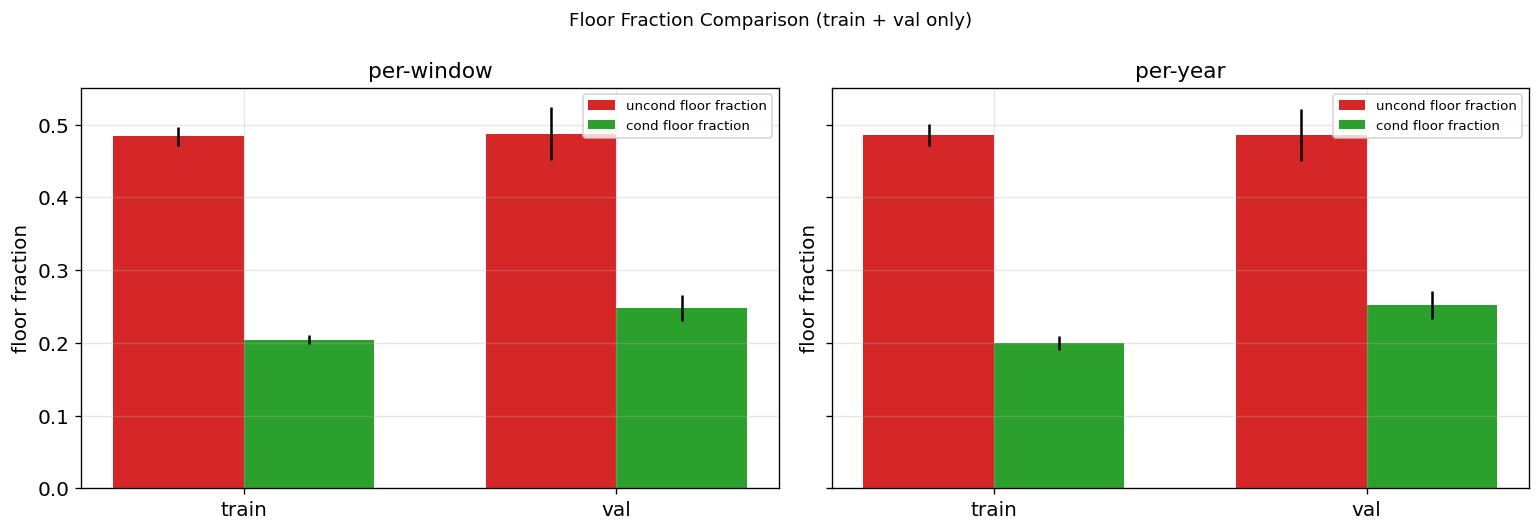

In [14]:
# Diagnostic plot: floor_fraction

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, gran in zip(axes, ("per-window", "per-year")):
    sub = results_df[results_df["granularity"] == gran].reset_index(drop=True)
    x   = np.arange(len(sub))
    w   = 0.35

    ax.bar(x - w/2, sub["uncond_floor_fraction_mean"], yerr=sub["uncond_floor_fraction_std"], width=w,
           color="C3", label="uncond floor fraction")
    ax.bar(x + w/2, sub["cond_floor_fraction_mean"],   yerr=sub["cond_floor_fraction_std"], width=w,
           color="C2", label="cond floor fraction")

    ax.set_xticks(x); ax.set_xticklabels(sub["split"])
    ax.set_title(f"{gran}"); ax.set_ylabel("floor fraction")
    ax.legend(fontsize=8); ax.axhline(0, color="k", linewidth=0.4)
fig.suptitle("Floor Fraction Comparison (train + val only)", fontsize=11)
plt.tight_layout(); plt.show()

---
## Task 59 — Visualize the comparison

Two figures earn their place here. The first is the headline result — a
bar chart of NLL per (granularity × split) for the three models, with
error bars on the combined columns. The second is the per-cycle NLL
breakdown — which cycles benefit most from conditioning, and which don't?
The breakdown is what surfaces whether the gain is uniform across the
data or driven by a few cycles.

Diagnostic plots worth including if you have the time:
- `floor_fraction` per combined run: how often did `max(eps, ...)` actually
  fire? A non-trivial floor fraction in the conditional model but not the
  unconditional model means conditioning is over-correcting some windows.
- The K-spread per cell: is the conditional column's spread tighter than
  the unconditional column's? If so, conditioning is reducing the
  sampling-variance contribution to NLL noise as expected.

Anything quantitative you spot here should land in the next iteration
on the model — most likely the experimentation week, where this notebook
serves as the validation oracle.


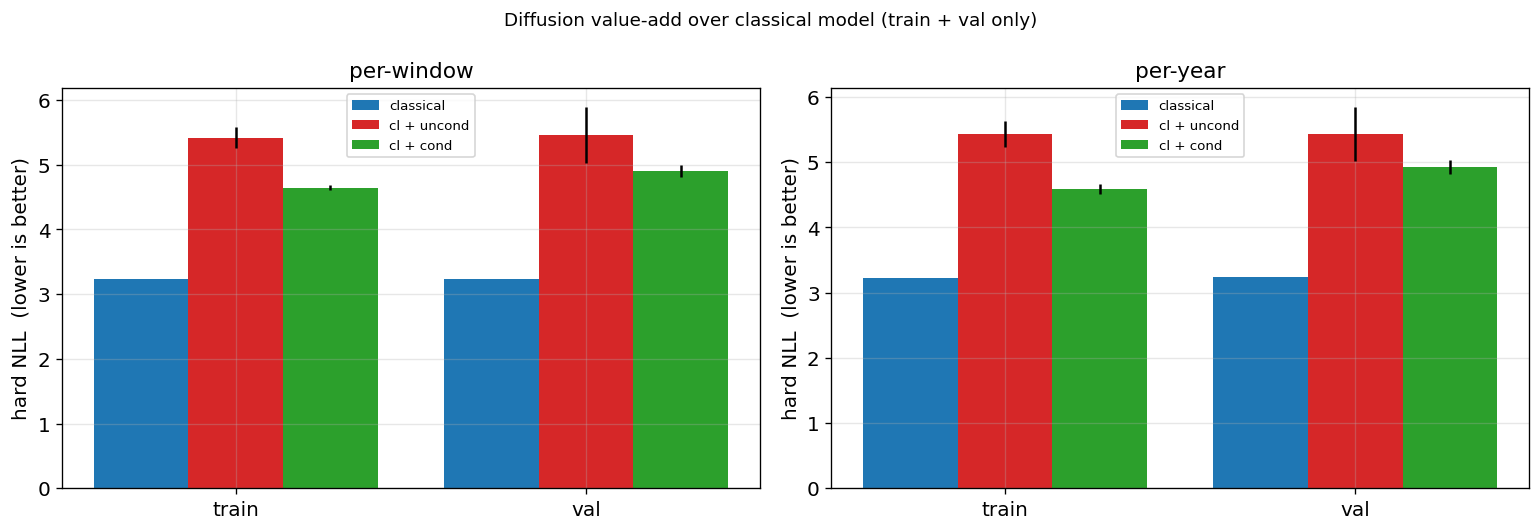

In [15]:
# Task 59 — headline bar chart + per-cycle breakdown.

# Reference workflow (headline chart only — per-cycle breakdown left as exercise):

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, gran in zip(axes, ("per-window", "per-year")):
    sub = results_df[results_df["granularity"] == gran].reset_index(drop=True)
    x   = np.arange(len(sub))
    w   = 0.27
    ax.bar(x - w, sub["classical"], width=w, color="C0", label="classical")
    ax.bar(x,     sub["uncond_mean"], yerr=sub["uncond_std"], width=w,
           color="C3", label="cl + uncond")
    ax.bar(x + w, sub["cond_mean"],   yerr=sub["cond_std"], width=w,
           color="C2", label="cl + cond")
    ax.set_xticks(x); ax.set_xticklabels(sub["split"])
    ax.set_title(f"{gran}"); ax.set_ylabel("hard NLL  (lower is better)")
    ax.legend(fontsize=8); ax.axhline(0, color="k", linewidth=0.4)
fig.suptitle("Diffusion value-add over classical model (train + val only)", fontsize=11)
plt.tight_layout(); plt.show()

### Visualizing Raw Combined Densities for Selected Blocks

To understand the source of high NLLs, we will examine the distributions of raw (un-floored) densities for a few representative blocks from the `per-window` validation set. This allows us to see how the diffusion residuals modify the classical Gaussian density before any `eps` clipping occurs. Specifically, we'll look for how frequently and how negatively the combined densities fall below zero or near zero.

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm
import numpy as np

def get_block_data(hcs_list, block_key_list, cond_samples_NK15, uncond_samples_NK15, classical_model, num_blocks=3, k_sample_idx=0):
    block_data = []
    # Use a local variable to map block keys to their index in block_key_list for efficient lookup
    block_key_to_idx = {key: idx for idx, key in enumerate(block_key_list)}

    selected_block_keys = []
    # Iterate through hcs_list to find actual blocks that are also in block_key_list
    # This ensures we only process blocks that have corresponding sample data
    for hc in hcs_list:
        for blk in hc["blocks"]:
            current_key = (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
            if current_key in block_key_to_idx:
                selected_block_keys.append(current_key)
            if len(selected_block_keys) >= num_blocks:
                break
        if len(selected_block_keys) >= num_blocks:
            break

    if not selected_block_keys:
        print("No blocks found matching the criteria.")
        return []

    for current_key in selected_block_keys:
        # Find the original hc and blk for the current_key
        # These next() calls are safe because selected_block_keys was built from hcs_list
        hc = next(h for h in hcs_list for blk_in_hc in h["blocks"] if (h["cycle"], h["hemisphere"], blk_in_hc["center_decimal"]) == current_key)
        block_found = next(blk_in_hc for blk_in_hc in hc["blocks"] if (hc["cycle"], hc["hemisphere"], blk_in_hc["center_decimal"]) == current_key)

        lats = block_found["lats"]
        tau = block_found["tau"]
        amplitude = hc["amplitude"]

        # Classical density
        mu = classical_model.mu(tau)
        sigma = classical_model.sigma(mu, amplitude)
        p_cl = sp_norm.pdf(lats, loc=mu, scale=sigma)

        # Bin the classical density for comparison with binned residuals
        # Create a finer grid for classical density for smoother visualization if needed
        fine_lats = np.linspace(0, 45, 100)
        p_cl_fine = sp_norm.pdf(fine_lats, loc=mu, scale=sigma)

        # Get residuals for this block and selected sample index
        # Use the block_key_to_idx to get the correct index in the sample arrays
        idx_in_sample_arrays = block_key_to_idx[current_key]

        uncond_residual = uncond_samples_NK15[idx_in_sample_arrays, k_sample_idx]
        cond_residual = cond_samples_NK15[idx_in_sample_arrays, k_sample_idx]

        # Calculate raw combined densities (before eps floor)
        bin_ix = np.clip(np.floor(lats / BIN_WIDTH).astype(int), 0, 14)
        p_raw_uncond = p_cl + uncond_residual[bin_ix]
        p_raw_cond = p_cl + cond_residual[bin_ix]

        block_data.append({
            "cycle": hc["cycle"],
            "hemisphere": hc["hemisphere"],
            "center_decimal": block_found["center_decimal"],
            "lats": lats,
            "p_cl": p_cl,
            "p_cl_fine": p_cl_fine,
            "fine_lats": fine_lats,
            "uncond_residual_binned": uncond_residual,
            "cond_residual_binned": cond_residual,
            "p_raw_uncond": p_raw_uncond,
            "p_raw_cond": p_raw_cond,
            "mu": mu,
            "sigma": sigma
        })
    return block_data

# Filter hcs to only 'val' split for per-window
hcs_per_window_val = [hc for hc in per_window if hc["split"] == "val"]

# Re-derive split-specific data for per-window val
# We need the keys, cond_samples, and uncond_samples corresponding to the per-window val split
split_keys_pw_val = set()
for hc in hcs_per_window_val:
    for blk in hc["blocks"]:
        split_keys_pw_val.add((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))

keep_ix_pw_val    = [i for i, k in enumerate(kw_keys) if k in split_keys_pw_val]
keys_split_pw_val = [kw_keys[i] for i in keep_ix_pw_val]
cond_split_pw_val   = kw_cond[keep_ix_pw_val]
uncond_split_pw_val = kw_uncond[keep_ix_pw_val]


# Get data for the first 3 validation blocks from the per-window validation set
selected_blocks_data = get_block_data(hcs_per_window_val, keys_split_pw_val, cond_split_pw_val, uncond_split_pw_val, classical, num_blocks=3)

print(f"Retrieved data for {len(selected_blocks_data)} blocks.")

Retrieved data for 3 blocks.


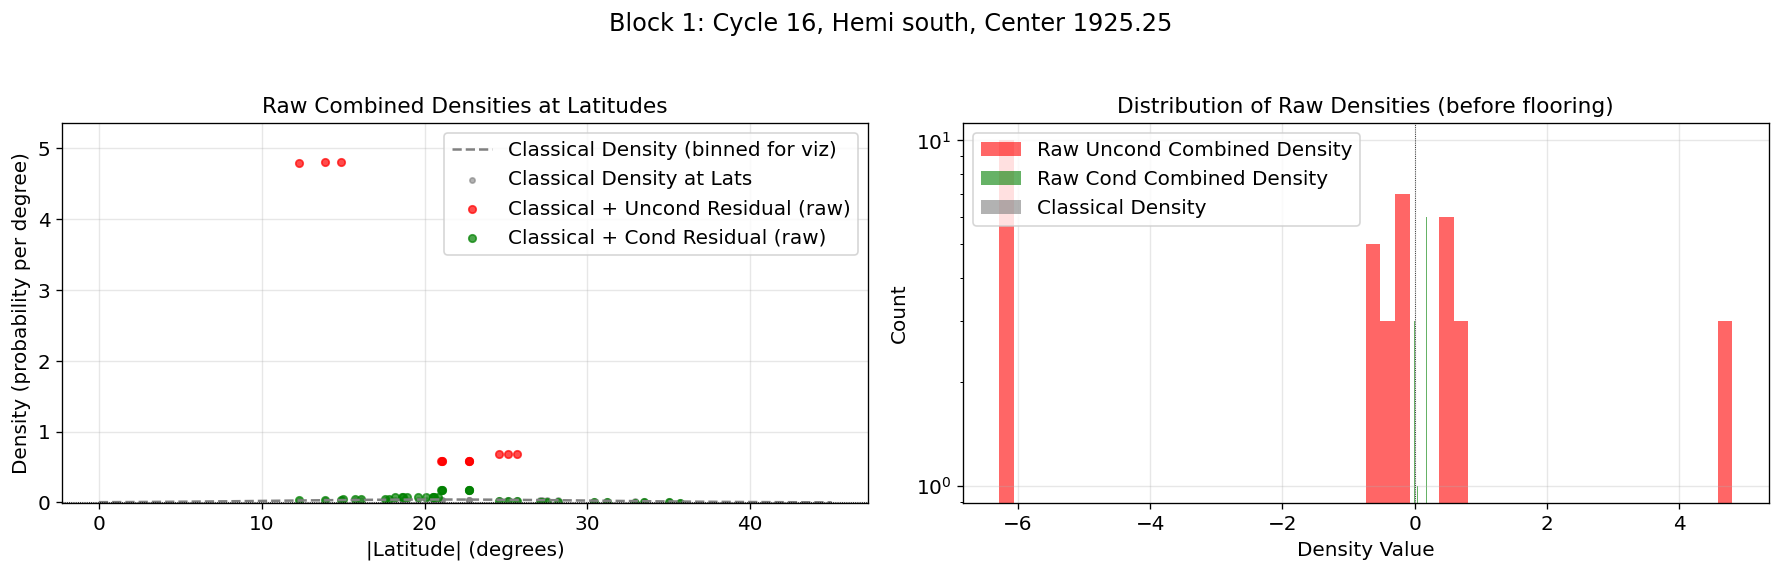

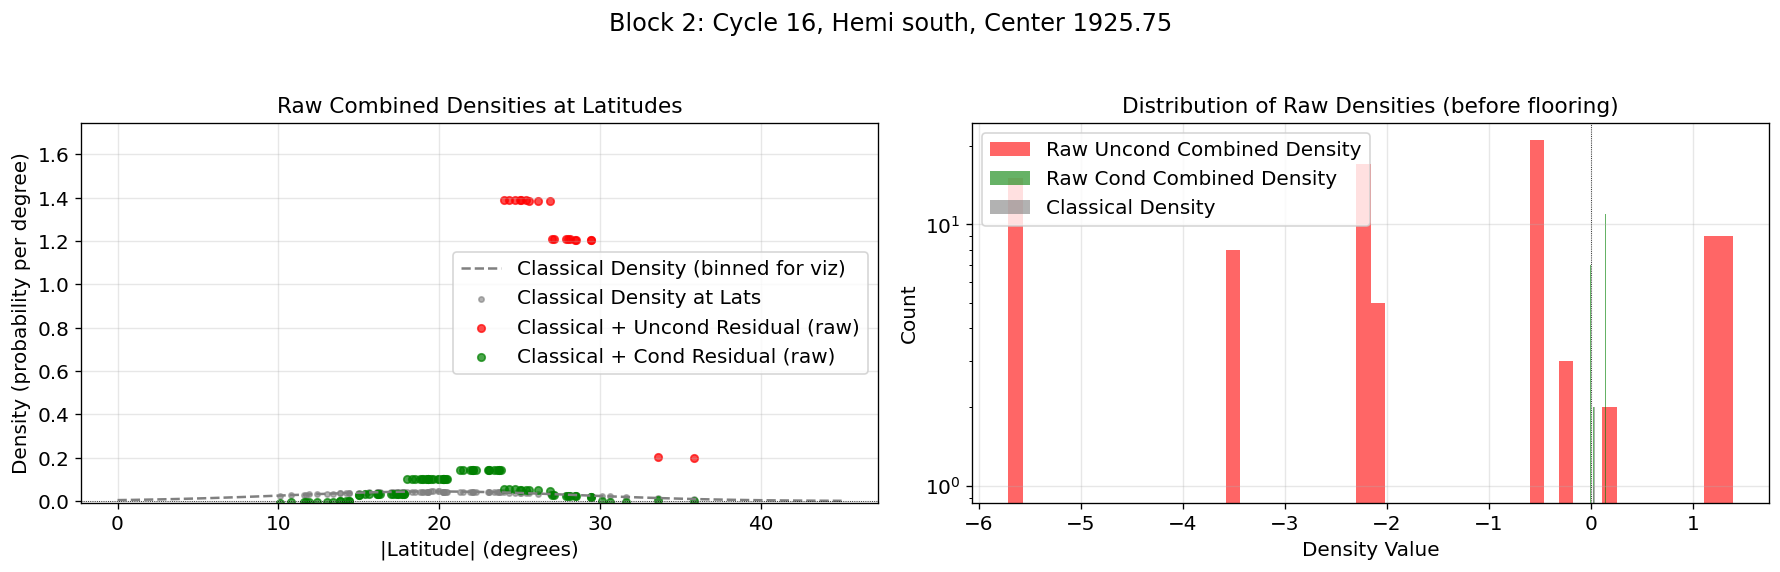

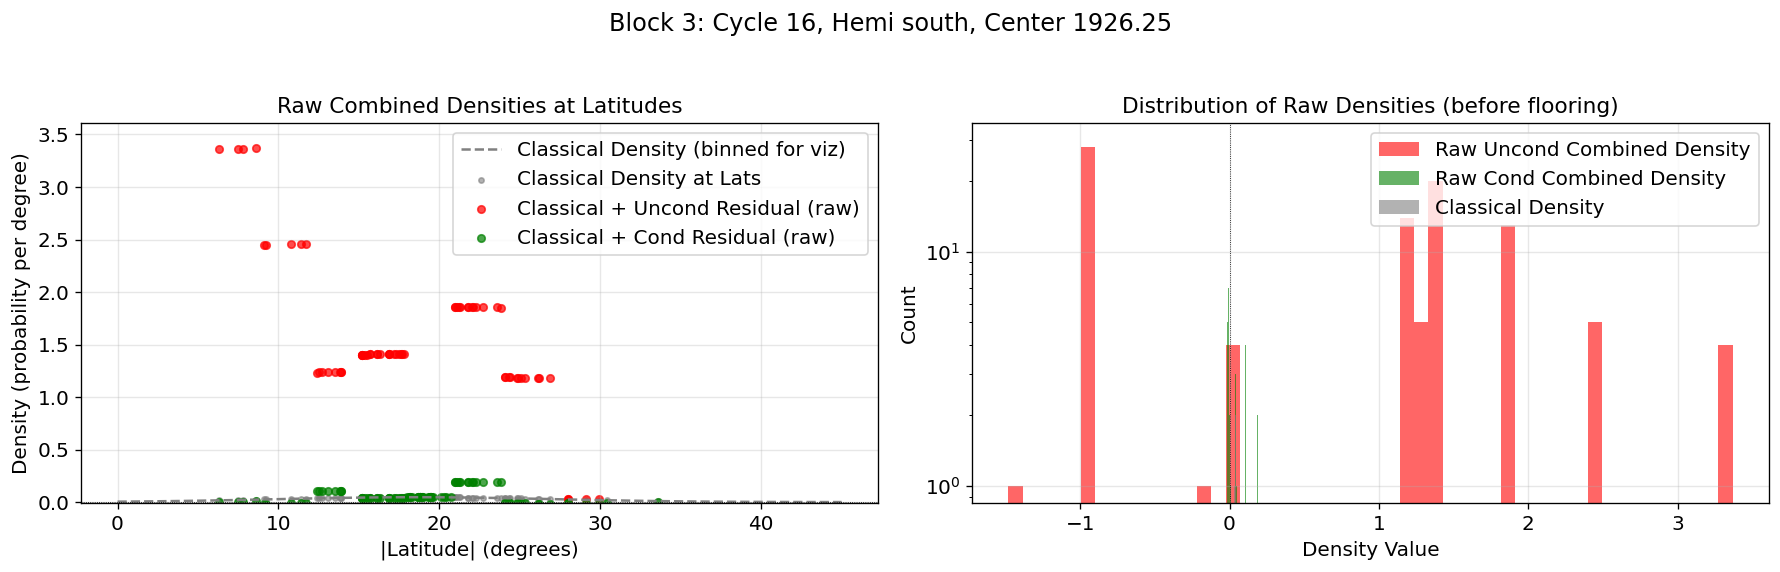

In [17]:
for i, block in enumerate(selected_blocks_data):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Block {i+1}: Cycle {block['cycle']}, Hemi {block['hemisphere']}, Center {block['center_decimal']:.2f}")

    # Plot 1: Original classical density and raw combined densities at original latitudes
    ax = axes[0]
    # Plot classical density as a line (using fine_lats for smoothness)
    ax.plot(block['fine_lats'], block['p_cl_fine'], label='Classical Density (binned for viz)', color='gray', linestyle='--')
    # Plot the individual lats and their classical densities (as points or scatter) for exact values
    ax.scatter(block['lats'], block['p_cl'], label='Classical Density at Lats', alpha=0.6, s=10, color='gray')

    ax.scatter(block['lats'], block['p_raw_uncond'], label='Classical + Uncond Residual (raw)', alpha=0.7, s=20, color='red')
    ax.scatter(block['lats'], block['p_raw_cond'], label='Classical + Cond Residual (raw)', alpha=0.7, s=20, color='green')

    ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
    ax.set_xlabel('|Latitude| (degrees)')
    ax.set_ylabel('Density (probability per degree)')
    ax.set_title('Raw Combined Densities at Latitudes')
    ax.legend()
    ax.set_ylim(bottom=-0.01)

    # Plot 2: Histograms of the raw densities
    ax = axes[1]
    ax.hist(block['p_raw_uncond'], bins=50, alpha=0.6, label='Raw Uncond Combined Density', color='red')
    ax.hist(block['p_raw_cond'], bins=50, alpha=0.6, label='Raw Cond Combined Density', color='green')
    ax.hist(block['p_cl'], bins=50, alpha=0.6, label='Classical Density', color='gray')

    ax.axvline(0, color='k', linestyle=':', linewidth=0.5)
    ax.set_xlabel('Density Value')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Raw Densities (before flooring)')
    ax.legend()
    ax.set_yscale('log') # Log scale for y-axis to see small values better

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

These plots show the *raw* combined densities before the `eps` floor is applied. Notice the regions where `p_raw_uncond` or `p_raw_cond` dip below zero, or are extremely small. These are the values that get clipped to `eps` and contribute to the `floor_fraction`.

Now, let's also visualize the direct residuals themselves. This can provide insight into the patterns the diffusion models are adding or subtracting from the classical density within each latitude bin.

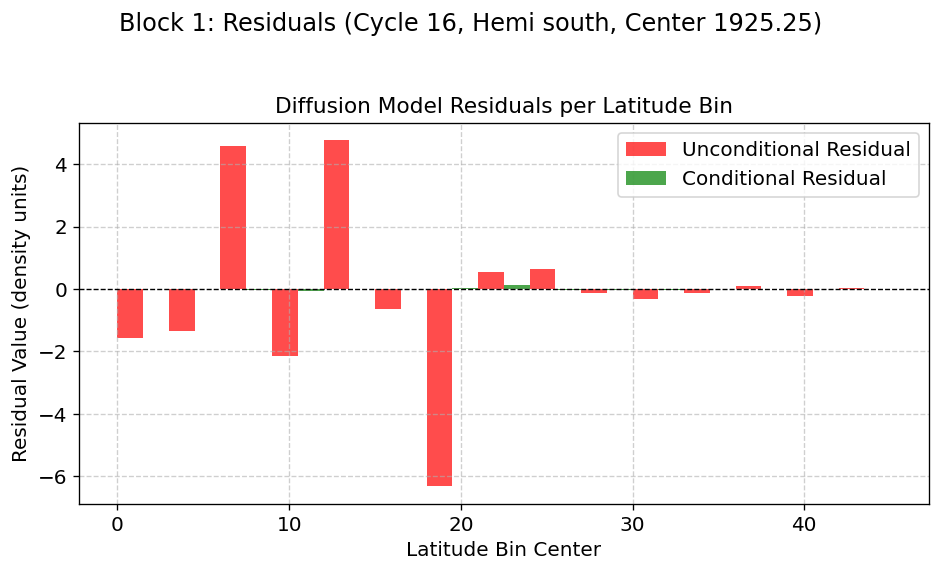

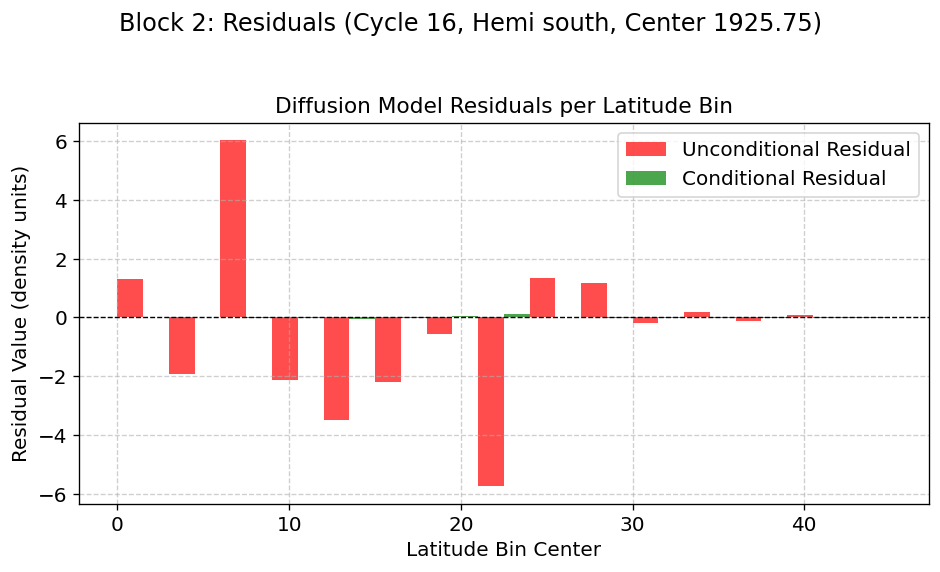

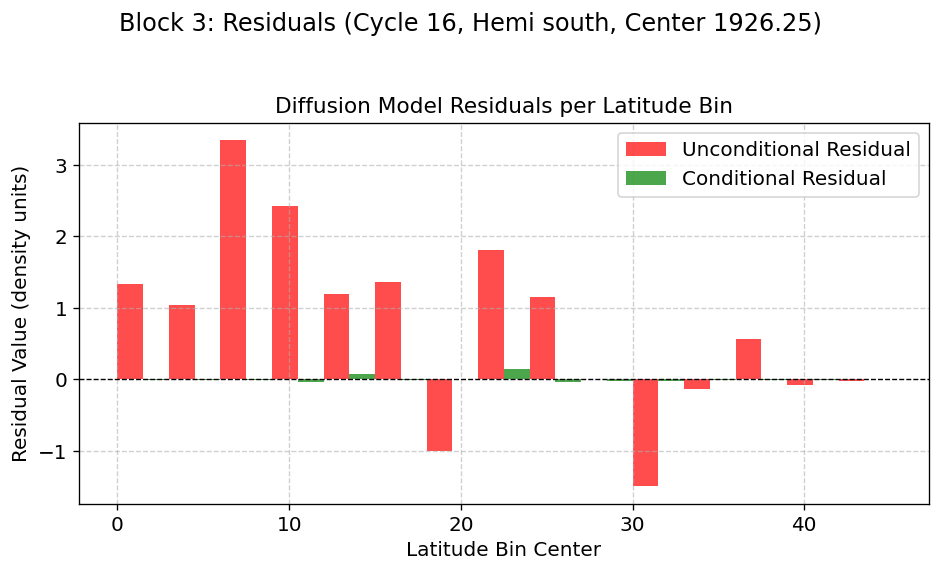

In [18]:
for i, block in enumerate(selected_blocks_data):
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"Block {i+1}: Residuals (Cycle {block['cycle']}, Hemi {block['hemisphere']}, Center {block['center_decimal']:.2f})")

    ax.bar(BIN_CENTERS - BIN_WIDTH/4, block['uncond_residual_binned'], width=BIN_WIDTH/2, label='Unconditional Residual', color='red', alpha=0.7)
    ax.bar(BIN_CENTERS + BIN_WIDTH/4, block['cond_residual_binned'], width=BIN_WIDTH/2, label='Conditional Residual', color='green', alpha=0.7)

    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Latitude Bin Center')
    ax.set_ylabel('Residual Value (density units)')
    ax.set_title('Diffusion Model Residuals per Latitude Bin')
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

---
## Reading the numbers, and what to do next

Three interpretive lines through the comparison table:

**Direction of the headline.** Is `classical + conditional` < `classical
alone` on validation? If yes and the margin is much larger than the K-σ
spread, the conditioning is doing useful work. If yes but inside the
K-σ spread, you have evidence of motion in the right direction but
sampling noise is a sizeable fraction of the signal — more samples
(K = 50 or 100) would tighten the comparison. If no, look at the
`uncond_delta` column: if both combined columns are *worse* than
classical, the diffusion machinery is making the density less
calibrated, not more, and the next iteration should focus on whether
the residuals are over-correcting (high `floor_fraction`).

**Conditioning specifically.** The interesting comparison is not just
combined vs. classical but combined-conditional vs. combined-
unconditional. If both columns are equally good (or equally bad), the
conditioning machinery is not earning its keep, even if residual
addition in general is helping. If the conditional column is meaningfully
better, you are measuring exactly the diffusion model's targeting
ability — the headline finding of Week 09.

**Per-window vs. per-year.** Per-window NLL is the diffusion model's
home turf — each window has its own residual, sampled at its own
conditioning. Per-year NLL aggregates lats over two windows but only
asks for one diffusion sample at the year-center conditioning, so the
diffusion model is doing less work per per-year block. Expect the
per-year improvement to be smaller than the per-window one; the gap
between them tells you how much the 6-month granularity is itself
contributing to the value-add.

**What about the test set?** The test split has been deliberately
untouched throughout this notebook. After you finish all model selection
(prompt iteration, hyperparameter search, architecture changes —
whatever the experimentation week brings), the test set gets opened
*once*, the same comparison table gets computed *once*, and that table
is the program's final scoreboard. Touching the test set before that
final measurement is the most common way real ML projects accidentally
inflate their reported performance, and the discipline of leaving it
alone is — in the long run — more valuable than any specific
architectural choice we've made over the last three weeks.

**The test set will only be used at the very, very end so don't use it for anything until told otherwise.**




### Task: Experiment with different `eps` values for `hard_nll_combined`

To address the over-correction and high `floor_fraction`, we will now evaluate the NLL and `floor_fraction` metrics using a range of `eps` (epsilon) values. This `eps` value serves as the minimum floor for the combined density $p_{\mathrm{comb}}(\ell) = \max\!\left(\varepsilon,\, p_{\mathrm{cl}}(\ell) + r[\mathrm{bin}(\ell)]\right)$.

By testing different `eps` values, we can observe:
- How sensitive the NLL is to the flooring threshold.
- Whether a higher `eps` might reduce the overall NLL by penalizing excessively negative-going residuals more harshly.
- How the `floor_fraction` changes, indicating the frequency of density values being clipped.

In [19]:
# Define a range of epsilon values to test
eps_values_to_test = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

# Initialize a list to store results for each epsilon
eps_sweep_rows = []

for eps_val in eps_values_to_test:
    print(f"\nEvaluating with eps = {eps_val}")
    for gran_name, hcs, keys, cond_s, uncond_s in [
        ("per-window", per_window, kw_keys, kw_cond, kw_uncond),
        ("per-year",   per_year,   ky_keys, ky_cond, ky_uncond),
    ]:
        for split in ("train", "val"):
            hcs_split = filter_split(hcs, split)

            # Index into samples for this split's keys.
            split_keys = set()
            for hc in hcs_split:
                for blk in hc["blocks"]:
                    split_keys.add((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))
            keep_ix    = [i for i, k in enumerate(keys) if k in split_keys]
            keys_split = [keys[i] for i in keep_ix]
            cond_split   = cond_s[keep_ix]
            uncond_split = uncond_s[keep_ix]

            nll_cl, det_cl = hard_nll_classical(classical, hcs_split)
            nll_u_K, floor_u_K = k_run_combined(hcs_split, keys_split, uncond_split, eps_override=eps_val)
            nll_c_K, floor_c_K = k_run_combined(hcs_split, keys_split, cond_split, eps_override=eps_val)

            eps_sweep_rows.append({
                "eps":              eps_val,
                "granularity"   : gran_name,
                "split"         : split,
                "n_blocks"      : det_cl["included"],
                "coverage"      : det_cl["coverage"],
                "classical"     : nll_cl,
                "uncond_mean"   : nll_u_K.mean(),  "uncond_std": nll_u_K.std(),
                "cond_mean"     : nll_c_K.mean(),  "cond_std":   nll_c_K.std(),
                "uncond_delta"  : nll_u_K.mean() - nll_cl,
                "cond_delta"    : nll_c_K.mean() - nll_cl,
                "uncond_floor_fraction_mean": floor_u_K.mean(),
                "uncond_floor_fraction_std": floor_u_K.std(),
                "cond_floor_fraction_mean": floor_c_K.mean(),
                "cond_floor_fraction_std": floor_c_K.std(),
            })

results_df_eps_sweep = pd.DataFrame(eps_sweep_rows)
display(results_df_eps_sweep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


Evaluating with eps = 1e-08

Evaluating with eps = 1e-07

Evaluating with eps = 1e-06

Evaluating with eps = 1e-05

Evaluating with eps = 0.0001

Evaluating with eps = 0.001


'   eps granularity split  n_blocks  coverage  classical  uncond_mean  uncond_std  cond_mean  cond_std  uncond_delta  cond_delta  uncond_floor_fraction_mean  uncond_floor_fraction_std  cond_floor_fraction_mean  cond_floor_fraction_std\n0.0000  per-window train       232    1.0000     3.2302       8.7564      0.2551     5.8384    0.0788        5.5262      2.6083                      0.4836                     0.0134                    0.2042                   0.0062\n0.0000  per-window   val        55    1.0000     3.2396       8.8294      0.6826     6.3684    0.1870        5.5898      3.1287                      0.4876                     0.0367                    0.2482                   0.0178\n0.0000    per-year train       125    1.0000     3.2258       8.7928      0.3090     5.7291    0.1448        5.5671      2.5033                      0.4858                     0.0153                    0.2000                   0.0095\n0.0000    per-year   val        29    1.0000     3.2476    

### Analysis of `eps` impact on NLL and Floor Fraction

The table above shows the NLL values and floor fractions for different `eps` thresholds. Let's visualize these trends to better understand the trade-offs involved in choosing an `eps` value.

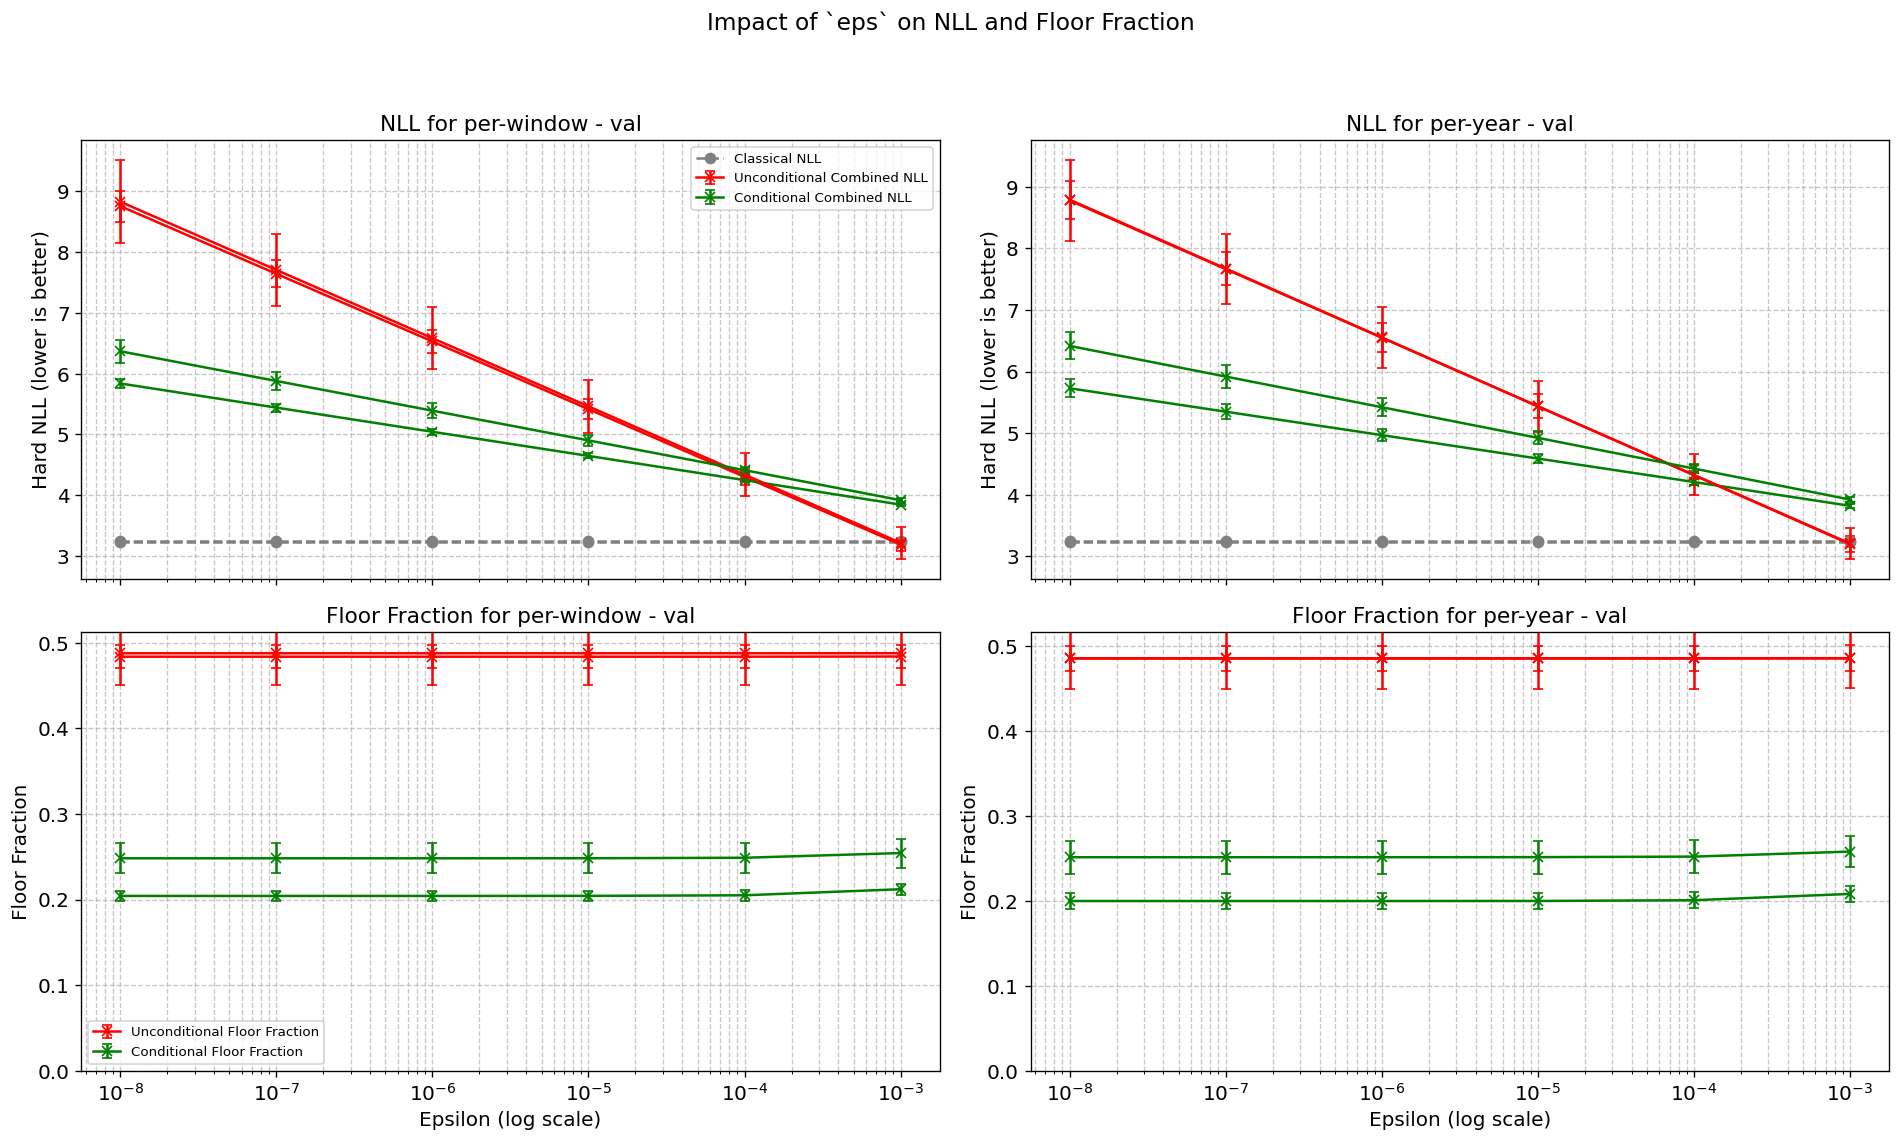

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle("Impact of `eps` on NLL and Floor Fraction", fontsize=14)

for i, gran_name in enumerate(["per-window", "per-year"]):
    for j, split in enumerate(["train", "val"]):
        ax_nll = axes[0, i] # NLL plot for this granularity
        ax_floor = axes[1, i] # Floor fraction plot for this granularity

        subset = results_df_eps_sweep[(results_df_eps_sweep["granularity"] == gran_name) & (results_df_eps_sweep["split"] == split)]

        # Plot NLLs
        ax_nll.plot(subset["eps"], subset["classical"], label="Classical NLL", marker='o', linestyle='--', color='gray')
        ax_nll.errorbar(subset["eps"], subset["uncond_mean"], yerr=subset["uncond_std"], label="Unconditional Combined NLL", marker='x', capsize=3, color='red')
        ax_nll.errorbar(subset["eps"], subset["cond_mean"], yerr=subset["cond_std"], label="Conditional Combined NLL", marker='x', capsize=3, color='green')
        ax_nll.set_title(f"NLL for {gran_name} - {split}")
        ax_nll.set_ylabel("Hard NLL (lower is better)")
        ax_nll.set_xscale('log')
        ax_nll.grid(True, which="both", ls="--", alpha=0.7)
        if i == 0 and j == 0: # Add legend only once
            ax_nll.legend(fontsize=8)

        # Plot Floor Fractions
        ax_floor.errorbar(subset["eps"], subset["uncond_floor_fraction_mean"], yerr=subset["uncond_floor_fraction_std"], label="Unconditional Floor Fraction", marker='x', capsize=3, color='red')
        ax_floor.errorbar(subset["eps"], subset["cond_floor_fraction_mean"], yerr=subset["cond_floor_fraction_std"], label="Conditional Floor Fraction", marker='x', capsize=3, color='green')
        ax_floor.set_title(f"Floor Fraction for {gran_name} - {split}")
        ax_floor.set_ylabel("Floor Fraction")
        ax_floor.set_xlabel("Epsilon (log scale)")
        ax_floor.set_xscale('log')
        ax_floor.grid(True, which="both", ls="--", alpha=0.7)
        ax_floor.set_ylim(bottom=0)
        if i == 0 and j == 0: # Add legend only once
            ax_floor.legend(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()